In [ ]:
%load_ext autoreload
%autoreload 2

import json

pattern = "pattern-3"

entrypoint = pattern
app_cwl_file = f"../cwl-workflow/{pattern}.cwl"

with open(f"../cwl-workflow/{pattern}-inputs.json", "r") as f:
    app_inputs = json.load(f)

try:
    from docs.helpers import plot_cwl, wrap_cwl
except (ImportError, ModuleNotFoundError) as e:

    import os
    import sys

    module_path = os.path.abspath(os.path.join("."))  # or the path to your source code
    sys.path.insert(0, module_path)

from helpers import WorkflowViewer, WorkflowWrapper, additional_inputs
from cwl_loader import dump_cwl
from IPython.display import Markdown, display
import json

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
wf = WorkflowViewer.from_file(app_cwl_file, entrypoint)

2025-12-03 10:34:19.831 | DEBUG    | cwl_loader:load_cwl_from_location:228 - Loading CWL document from ../cwl-workflow/pattern-3.cwl...


2025-12-03 10:34:19.832 | DEBUG    | cwl_loader:_load_cwl_from_stream:231 - Reading stream from ../cwl-workflow/pattern-3.cwl...
2025-12-03 10:34:19.841 | DEBUG    | cwl_loader:load_cwl_from_stream:203 - CWL data of type <class 'ruamel.yaml.comments.CommentedMap'> successfully loaded from stream
2025-12-03 10:34:19.842 | DEBUG    | cwl_loader:load_cwl_from_yaml:130 - Updating the model from version 'v1.0' to version 'v1.2'...
2025-12-03 10:34:19.842 | DEBUG    | cwl_loader:load_cwl_from_yaml:141 - Raw CWL document successfully updated to v1.2!
2025-12-03 10:34:19.842 | DEBUG    | cwl_loader:load_cwl_from_yaml:145 - Parsing the raw CWL document to the CWL Utils DOM...
2025-12-03 10:34:20.082 | DEBUG    | cwl_loader:load_cwl_from_yaml:158 - Raw CWL document successfully parsed to the CWL Utils DOM!
2025-12-03 10:34:20.083 | DEBUG    | cwl_loader:load_cwl_from_yaml:160 - Dereferencing the steps[].run...
2025-12-03 10:34:20.083 | DEBUG    | cwl_loader:_on_process:78 - Checking if ../cwl-wo

## Application Package Pattern 3

The CWL includes: 

- scatter on an input parameter of type `Directory[]`
- one output parameter of type `Directory`

This scenario typically takes as input a stack of acquisitions, applies an aggregation algorithm and produces a result

Implementation: detect water bodies taking as input a list of Landsat-8/9 acquisitions producing a STAC Catalog with n STAC Items

In [1]:
wf.display_state_diagram()

NameError: name 'wf' is not defined

### Inputs

In [20]:
wf.display_inputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `aoi` | `string` | area of interest | area of interest as a bounding box |
| `epsg` | `string` | EPSG code | EPSG code |
| `bands` | `string[]` | bands used for the NDWI | bands used for the NDWI |
| `items` | `Directory[]` | Landsat-8/9 acquisition reference | Landsat-8/9 acquisition reference |


### Steps

In [21]:
wf.display_steps()

| Id | Runs | Label | Doc |
| --- | --- | --- | --- |
| `step` | `#clt` | None | None |


### Outputs

In [22]:
wf.display_outputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `water_bodies` | `Directory[]` | Water bodies detected | Water bodies detected based on the NDWI and otsu threshold |


## Data flow management

In [23]:
w = WorkflowWrapper(workflow=wf.workflow, entrypoint=entrypoint)
wrapped = w.wrap()

app_cwl_file = f".{entrypoint}.cwl"

with open(app_cwl_file, "w") as f:
    dump_cwl(process=wrapped, stream=f)

2025-12-03 10:34:20.905 | DEBUG    | cwl_loader:load_cwl_from_location:228 - Loading CWL document from https://raw.githubusercontent.com/eoap/application-package-patterns/refs/heads/develop/templates/stage-in.cwl...
2025-12-03 10:34:20.986 | DEBUG    | cwl_loader:_load_cwl_from_stream:231 - Reading stream from https://raw.githubusercontent.com/eoap/application-package-patterns/refs/heads/develop/templates/stage-in.cwl...
2025-12-03 10:34:20.990 | DEBUG    | cwl_loader:load_cwl_from_stream:203 - CWL data of type <class 'ruamel.yaml.comments.CommentedMap'> successfully loaded from stream
2025-12-03 10:34:20.991 | DEBUG    | cwl_loader:load_cwl_from_yaml:130 - Updating the model from version 'v1.0' to version 'v1.2'...
2025-12-03 10:34:20.991 | DEBUG    | cwl_loader:load_cwl_from_yaml:141 - Raw CWL document successfully updated to v1.2!
2025-12-03 10:34:20.992 | DEBUG    | cwl_loader:load_cwl_from_yaml:145 - Parsing the raw CWL document to the CWL Utils DOM...
2025-12-03 10:34:21.405 | DE

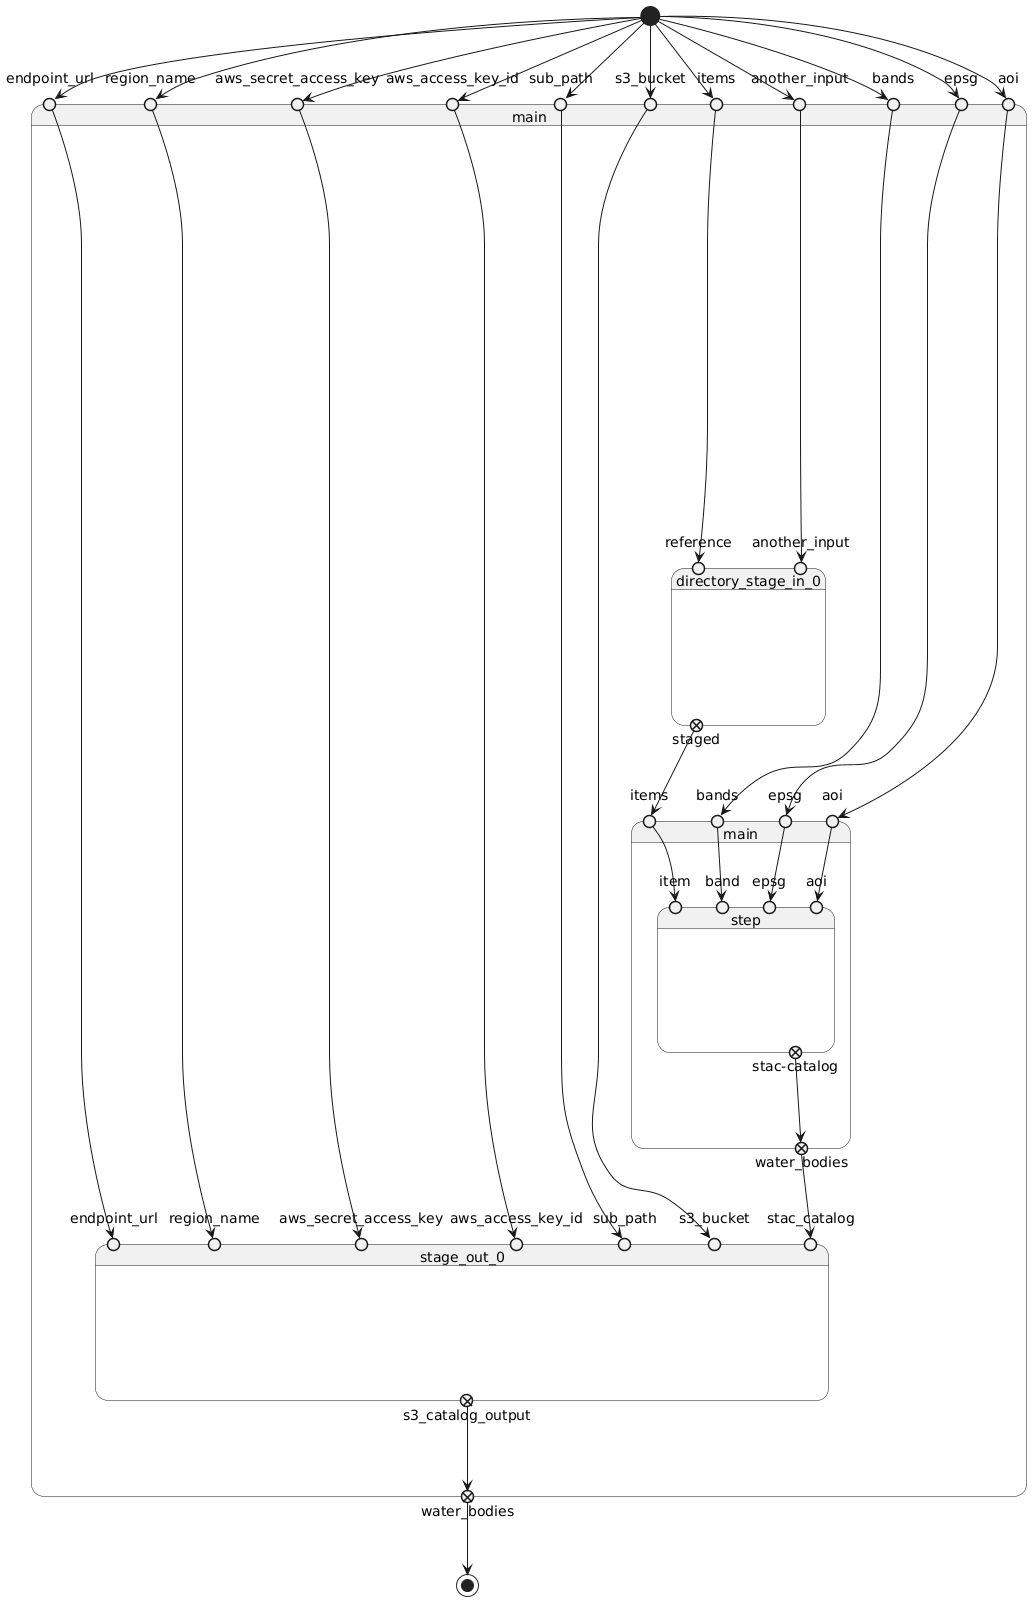

In [ ]:
wf = WorkflowViewer(cwl_file=app_cwl_file, workflow=wrapped, entrypoint="main")

wf.display_state_diagram()

### Workflow sequence diagram

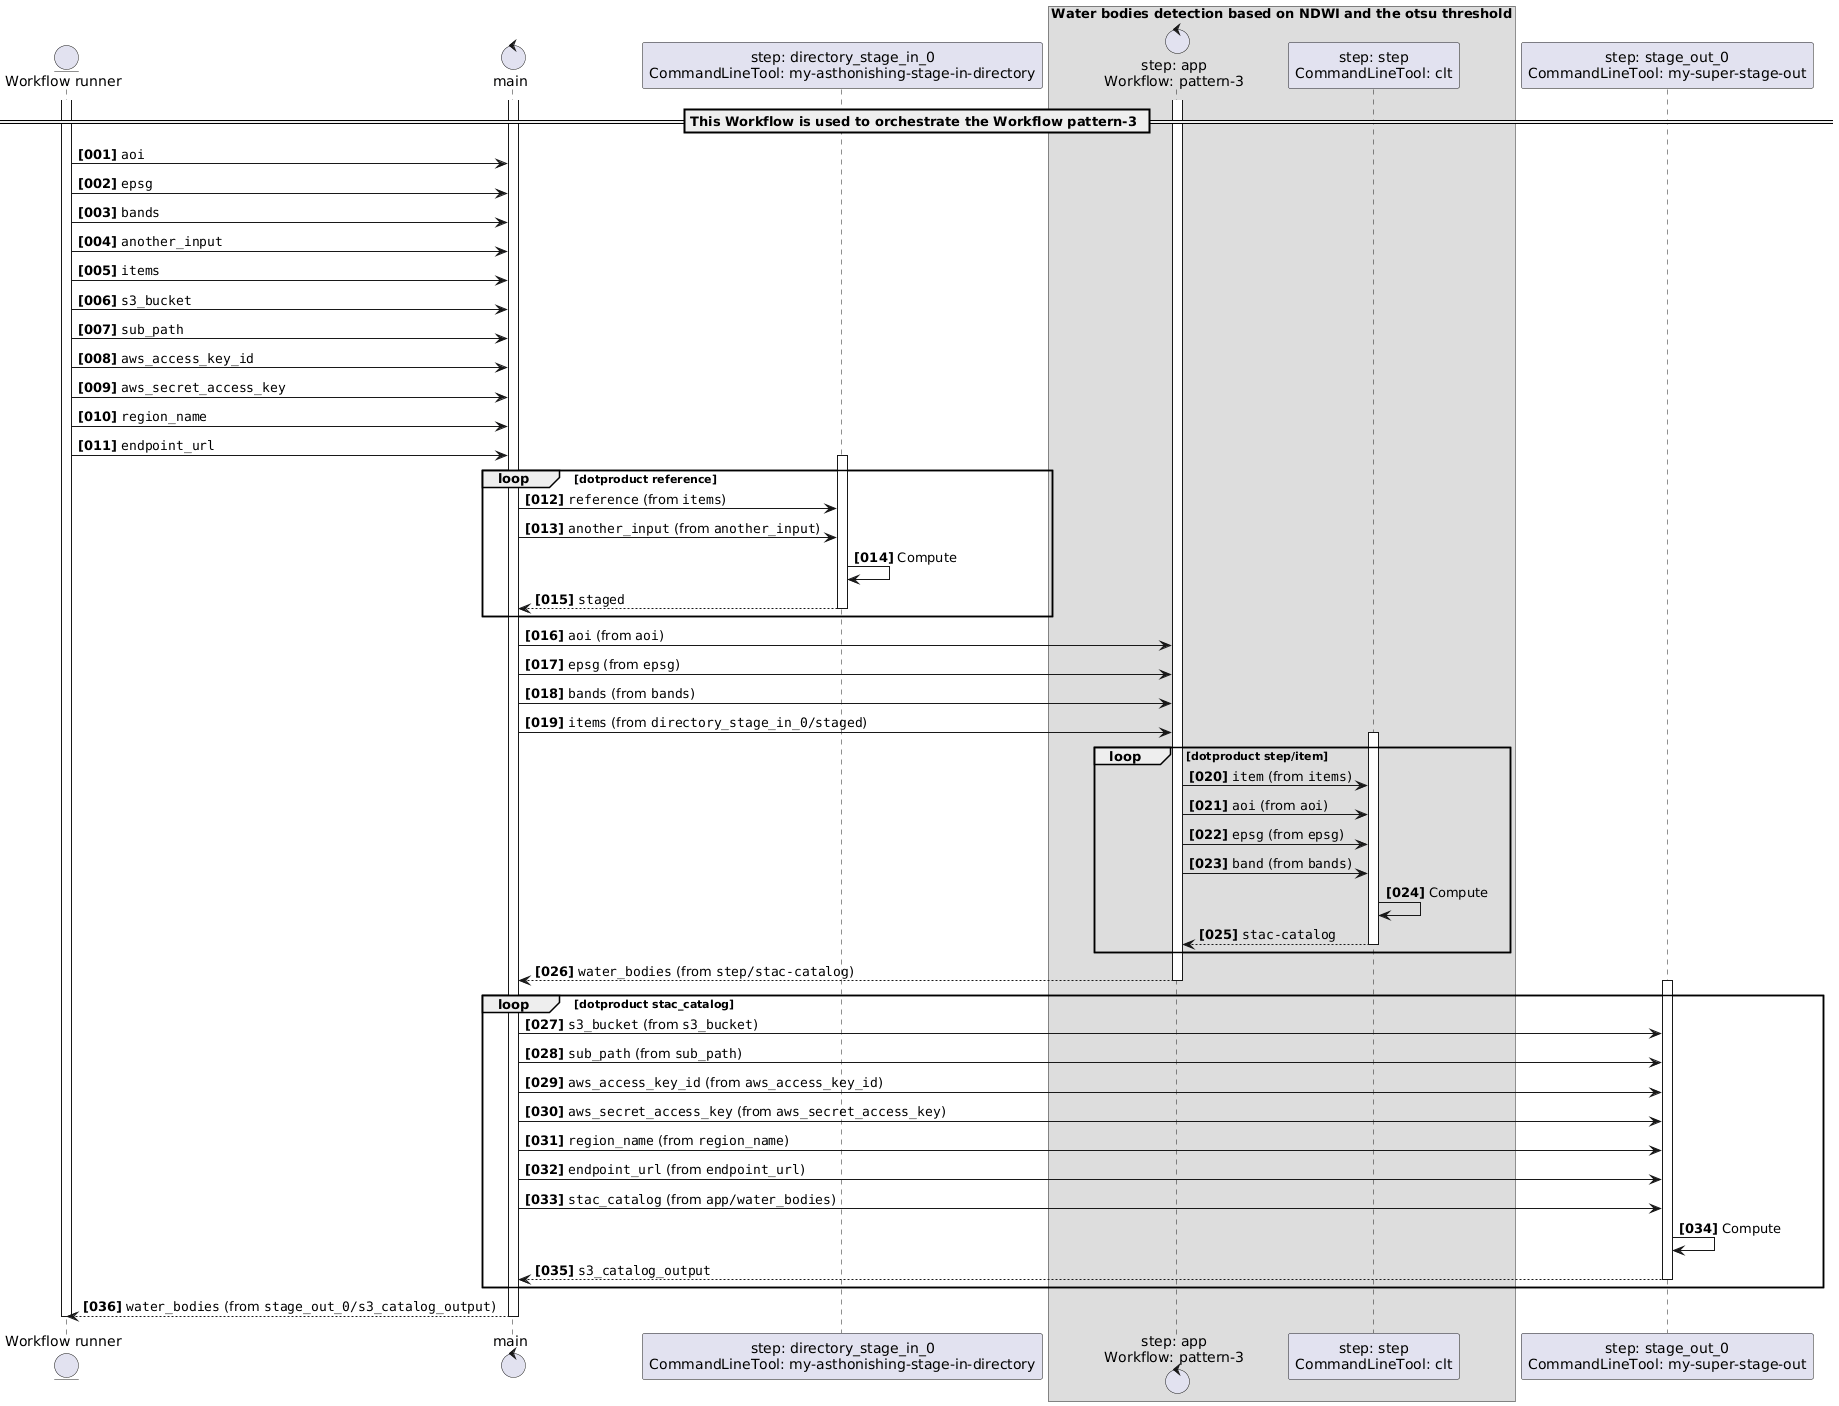

In [25]:
wf.display_sequence_diagram()

### Inputs

In [26]:
wf.display_inputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `aoi` | `string` | area of interest - pattern-3/aoi | area of interest as a bounding box - This parameter is derived from pattern-3/aoi |
| `epsg` | `string` | EPSG code - pattern-3/epsg | EPSG code - This parameter is derived from pattern-3/epsg |
| `bands` | `string[]` | bands used for the NDWI - pattern-3/bands | bands used for the NDWI - This parameter is derived from pattern-3/bands |
| `another_input` | `string` | Another Input - my-asthonishing-stage-in-directory/another_input | An additional input for demonstration purposes - This parameter is derived from my-asthonishing-stage-in-directory/another_input |
| `items` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI[]` | Landsat-8/9 acquisition reference - pattern-3/items | Landsat-8/9 acquisition reference - This parameter is derived from pattern-3/items |
| `s3_bucket` | `string` | my-super-stage-out/s3_bucket | This parameter is derived from: my-super-stage-out/s3_bucket |
| `sub_path` | `string` | my-super-stage-out/sub_path | This parameter is derived from: my-super-stage-out/sub_path |
| `aws_access_key_id` | `string` | my-super-stage-out/aws_access_key_id | This parameter is derived from: my-super-stage-out/aws_access_key_id |
| `aws_secret_access_key` | `string` | my-super-stage-out/aws_secret_access_key | This parameter is derived from: my-super-stage-out/aws_secret_access_key |
| `region_name` | `string` | my-super-stage-out/region_name | This parameter is derived from: my-super-stage-out/region_name |
| `endpoint_url` | `string` | my-super-stage-out/endpoint_url | This parameter is derived from: my-super-stage-out/endpoint_url |


### Steps

In [27]:
wf.display_steps()

| Id | Runs | Label | Doc |
| --- | --- | --- | --- |
| `directory_stage_in_0` | `#my-asthonishing-stage-in-directory` | None | None |
| `app` | `#pattern-3` | None | None |
| `stage_out_0` | `#my-super-stage-out` | None | None |


### Outputs

In [28]:
wf.display_outputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `water_bodies` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI[]` | Water bodies detected | Water bodies detected based on the NDWI and otsu threshold |


## Execution


In [29]:
from cwltool.main import main
from io import StringIO
import argparse
import yaml

In [ ]:
with open(".params.yaml", "w") as f:
    yaml.dump({**app_inputs, **additional_inputs}, f)

md = f"""

### Inputs

```json
{json.dumps({**app_inputs, **additional_inputs}, indent=2)}
```
"""

display(Markdown(md))



### Inputs

```json
{
  "aoi": "-118.985,38.432,-118.183,38.938",
  "epsg": "EPSG:4326",
  "bands": [
    "green",
    "nir08"
  ],
  "items": [
    {
      "class": "https://raw.githubusercontent.com/eoap/schemas/main/url.yaml#URL",
      "value": "https://planetarycomputer.microsoft.com/api/stac/v1/collections/landsat-c2-l2/items/LC08_L2SP_042033_20231007_02_T1"
    },
    {
      "class": "https://raw.githubusercontent.com/eoap/schemas/main/url.yaml#URL",
      "value": "https://planetarycomputer.microsoft.com/api/stac/v1/collections/landsat-c2-l2/items/LC09_L2SP_042033_20231015_02_T1"
    }
  ]
}
```


In [32]:
parsed_args = argparse.Namespace(
    podman=False,
    debug=False,
    validate=False,
    outdir="./runs",
    workflow=f"{app_cwl_file}#main",
    job_order=[".params.yaml"],
)

stream_out = StringIO()
stream_err = StringIO()

res = main(
    args=parsed_args,
    stdout=stream_out,
    stderr=stream_err,
)

if res == 0:
    md = f"""

### Outputs

```json
{stream_out.getvalue()}
```
    """
else:
    md = f"""

### Errors

CWL execution terminated with errors:

```
{stream_err.getvalue()}
```
    """

display(Markdown(md))

KeyboardInterrupt: 